**Soil Health Index**

In [1]:
import pandas as pd

In [2]:
dc= pd.read_csv("Crop.csv")

In [3]:
# Normalizing NPK Values
for col in ['N', 'P', 'K']:
    col_min = dc[col].min()
    col_max = dc[col].max()

    if col_max - col_min == 0:
        dc[col + '_norm'] = 0.5   # neutral contribution
    else:
        dc[col + '_norm'] = (dc[col] - col_min) / (col_max - col_min)

In [4]:
# Normalize pH values to an ideal range
ideal_pH = 7.0
max_dev = max(abs(dc['ph'] - ideal_pH))

dc['pH_norm'] = 1 - (abs(dc['ph'] - ideal_pH) / max_dev)

In [5]:
# Create Soil Health Index (0–1 scale)

dc['SHI_raw'] = (
    0.25 * dc['N_norm'] +
    0.25 * dc['P_norm'] +
    0.25 * dc['K_norm'] +
    0.25 * dc['pH_norm']
)

In [6]:
dc['Soil_Health_Score'] = dc['SHI_raw'] * 100

In [7]:
# Soil health category
def soil_category(score):
    if score < 40:
        return 'Poor'
    elif score < 70:
        return 'Moderate'
    else:
        return 'Good'

dc['Soil_Category'] = dc['Soil_Health_Score'].apply(soil_category)

dc.head(20)

,N,P,K,temperature,humidity,ph,rainfall,label,N_norm,P_norm,K_norm,pH_norm,SHI_raw,Soil_Health_Score,Soil_Category
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,0.642857,0.264286,0.190,0.857803,0.488736,48.873639,Moderate
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,0.607143,0.378571,0.180,0.989101,0.538704,53.870370,Moderate
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,0.428571,0.357143,0.195,0.759614,0.435082,43.508218,Moderate
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,0.528571,0.214286,0.175,0.994393,0.478062,47.806245,Moderate
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,0.557143,0.264286,0.185,0.820192,0.456655,45.665519,Moderate
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice,0.492857,0.228571,0.185,0.978985,0.471353,47.135333,Moderate
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice,0.492857,0.357143,0.165,0.628297,0.410824,41.082423,Moderate
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice,0.671429,0.342857,0.175,0.633396,0.455670,45.567035,Moderate
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice,0.635714,0.350000,0.165,0.909977,0.515173,51.517276,Moderate
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice,0.485714,0.378571,0.165,0.810100,0.459847,45.984650,Moderate


In [8]:
from sklearn.model_selection import train_test_split

# Features (drop target + category + crop)
X = dc.drop(columns=['Soil_Health_Score', 'Soil_Category', 'SHI_raw', 'label'])

# Target
y = dc['Soil_Health_Score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestRegressor
model0 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model0.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model0.predict(X_test)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9928634932244002
RMSE: 1.0618754569713285


In [12]:
results = pd.DataFrame({
    'Actual_Soil_Health_Score': y_test.values,
    'Predicted_Soil_Health_Score': y_pred
})

results['Predicted_Soil_Category'] = results['Predicted_Soil_Health_Score'].apply(soil_category)

results.head(20)

,Actual_Soil_Health_Score,Predicted_Soil_Health_Score,Predicted_Soil_Category
0,44.599609,45.625024,Moderate
1,43.488064,43.184391,Moderate
2,50.795838,49.401506,Moderate
3,47.679527,47.673261,Moderate
4,68.314388,68.417829,Moderate
5,17.531123,19.211637,Poor
6,74.506469,74.053673,Good
7,31.333065,30.362313,Poor
8,32.792977,32.250491,Poor
9,39.389118,38.222403,Poor


In [13]:
import joblib
joblib.dump(model0, "soil_score.pkl")

['soil_score.pkl']

**Crop Predition**

In [14]:
import pandas as pd

In [15]:
df = pd.read_csv("Crop.csv")

print(df.shape)
print(df.info())
print(df['label'].value_counts())

(2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea 

In [16]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [17]:
df.duplicated().sum()

np.int64(0)

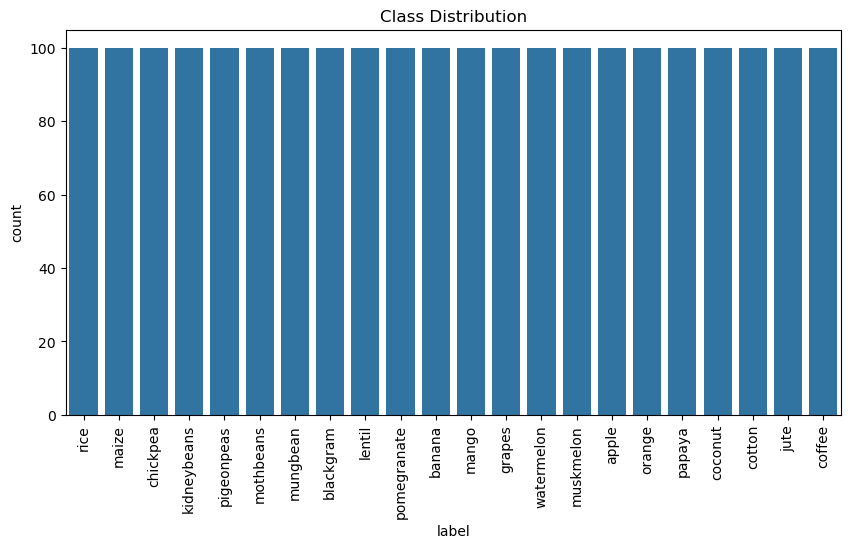

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

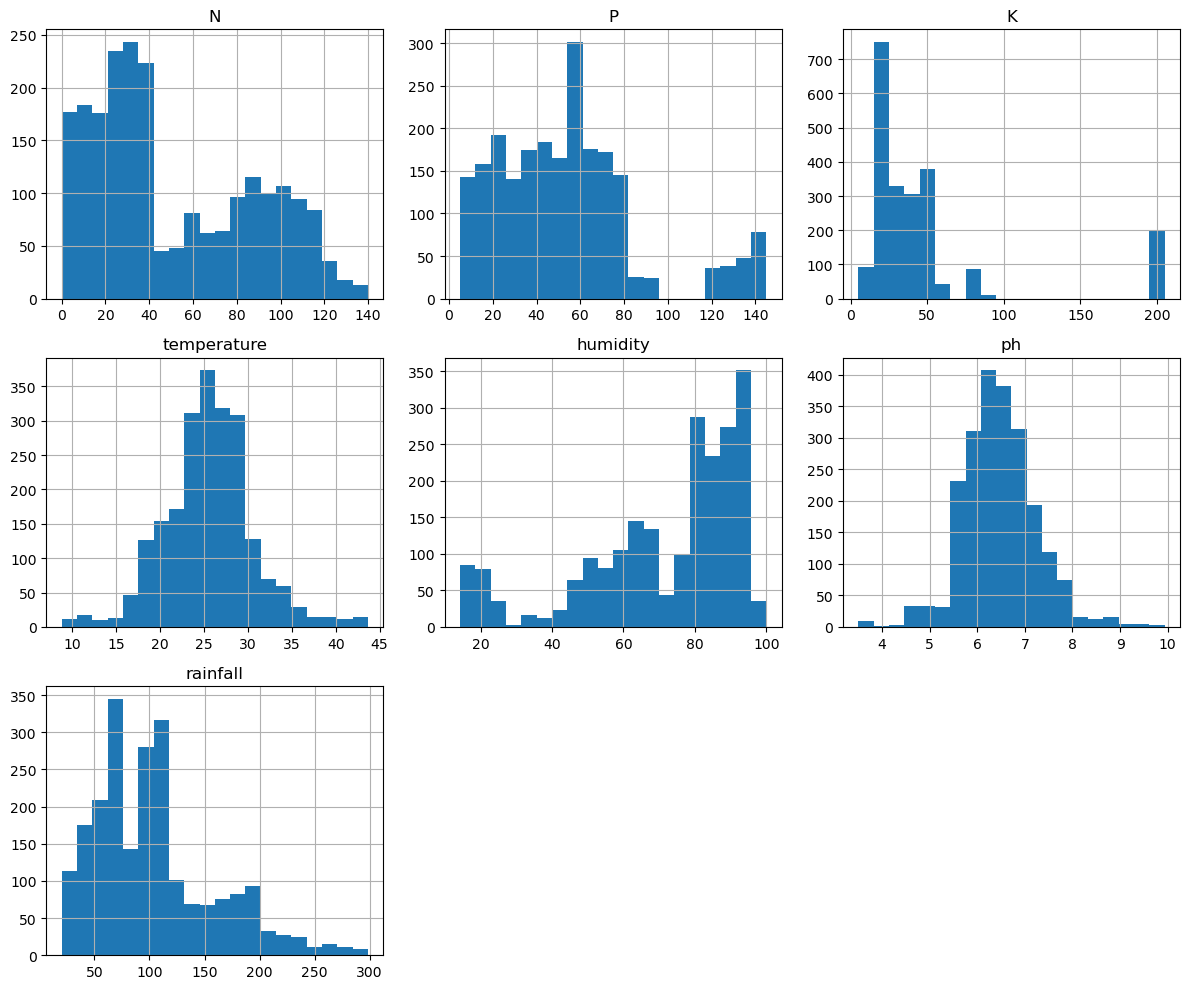

In [19]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

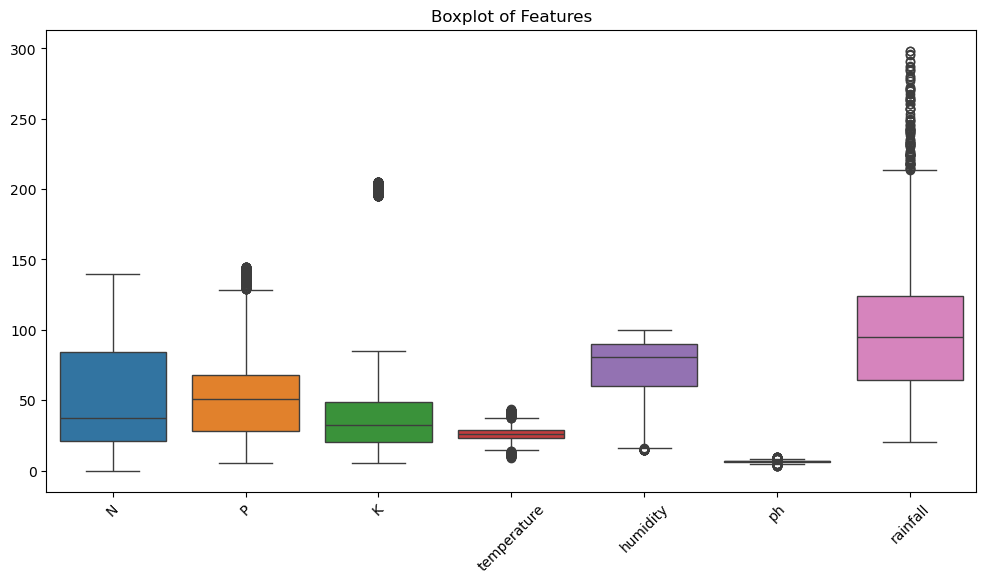

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("label", axis=1))
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

In [21]:
# Encode target
from sklearn.preprocessing import LabelEncoder
import joblib
X = df.drop("label", axis=1)
y = df["label"]


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save encoder (important for deployment)
joblib.dump(label_encoder, "crop_label_encoder.pkl")

print("Number of classes:", len(label_encoder.classes_))

Number of classes: 22


In [22]:
df["label"] = label_encoder.fit_transform(df["label"])

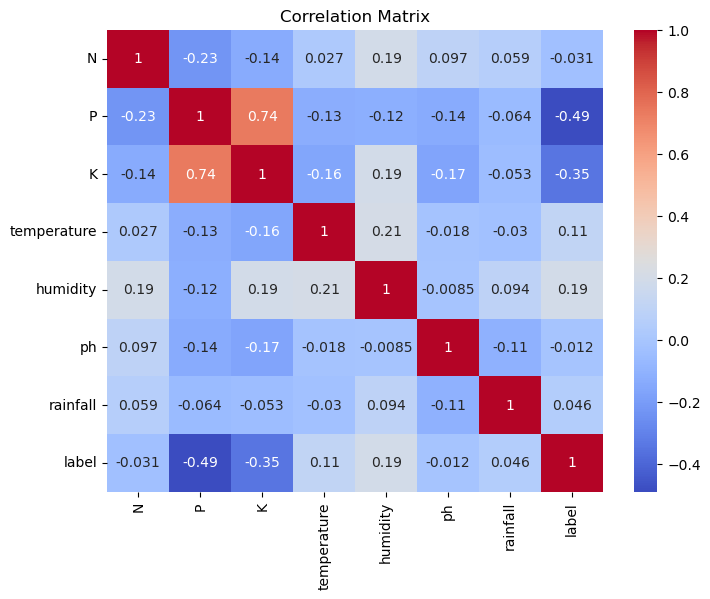

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [24]:
X = df.drop("label", axis=1)
y = df["label"]

In [25]:
X["N_P_ratio"] = X["N"] / (X["P"] + 1)
X["K_N_ratio"] = X["K"] / (X["N"] + 1)
X["rainfall_ph"] = X["rainfall"] * X["ph"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "crop_scaler.pkl")

['crop_scaler.pkl']

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Train Accuracy:", model.score(X_train_scaled, y_train))
print("Test Accuracy:", model.score(X_test_scaled, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9954545454545455


In [29]:
# Predict encoded labels
y_pred_encoded = model.predict(X_test_scaled)

# Decode to original crop names
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

print(y_pred_labels[:7])

['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice']


In [30]:
joblib.dump(model, "crop_model.pkl")

['crop_model.pkl']

**Fertilser**

In [31]:
import pandas as pd
# Reading excel file using pandas
df= pd.read_csv("CropF.csv")

# Print some part of data to understand it
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,fertilizer
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,DAP
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,Urea
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,Potassium Nitrate
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,TSP
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NPK 20-20-0


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [33]:
le_dict = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   int64  
 8   fertilizer   2200 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 154.8 KB


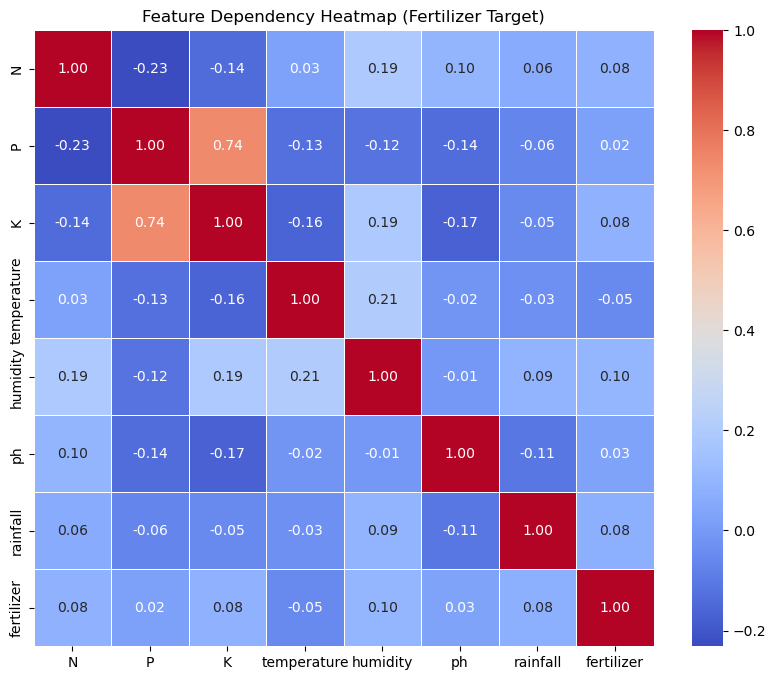

In [35]:
#3. Calculate Correlation
# We select the main features and our new target for the heatmap
corr_matrix = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'fertilizer']].corr()

# 4. Generate the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Feature Dependency Heatmap (Fertilizer Target)')
plt.savefig('fertilizer_heatmap.png')
plt.show()


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# Encode target
le = LabelEncoder()
y = le.fit_transform(df["fertilizer"])

# Features
X = df.drop(["fertilizer", "label"], axis=1)

# Create model
model2 = RandomForestClassifier(random_state=42)

# Train
model2.fit(X, y)

# Save model + encoder
joblib.dump(model2, "fertiliser.pkl")
joblib.dump(le, "fertiliser_encoder.pkl")

print("Model and encoder saved successfully!")
print("Classes:", le.classes_)

Model and encoder saved successfully!
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [39]:
print(le.classes_)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [37]:
#print("Final features used:", model2.feature_names_in_)

In [38]:
#import joblib
#joblib.dump(model2, "fertiliser.pkl")